# Exploring the Instance Space model

This notebook is the Python counterpart of MATLAB's `liveDemoIS.m`: it walks through the full
Instance Space Analysis pipeline stage by stage, first training a model with `build()`, then
applying it to unseen instances with `explore()`.

A trained model projects instances into the two-dimensional instance space, predicts which
algorithms will perform well on them, and checks whether they fall inside the trained performance
footprints. `build()` fits every stage from raw metadata; `explore()` applies an already-trained
model to new instances and re-fits nothing — it only reuses the parameters learned at training
time.

Run this notebook from the repository root.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import MultiPoint, MultiPolygon, Point

from instancespace.data.metadata import from_csv_file
from instancespace.data.options import InstanceSpaceOptions
from instancespace.instance_space import ExploreStage, InstanceSpace

INPUT_DIR = Path("tests/matlab_reference/input")

## Building a model

`build()` fits every stage from raw metadata, the Python equivalent of MATLAB's `buildIS.m`
calling each stage in turn and storing its result on the model:

| Python stage | What it does | MATLAB `buildIS.m` |
|---|---|---|
| `PreprocessingStage` | loads and filters the raw metadata | data loading / `opts` setup |
| `PrelimStage` | bounds outliers, then scales features and performance | `PRELIM` |
| `SiftedStage` | selects a predictive, low-redundancy feature subset | `SIFTED` |
| `PilotStage` | projects the (selected) features into the 2D instance space | `PILOT` |
| `CloisterStage` | estimates the empirical bounds of the instance space | `CLOISTER` |
| `PythiaStage` | trains one good/not-good classifier per algorithm | `PYTHIA` |
| `TraceStage` | builds each algorithm's performance footprint | `TRACE` |

CLOISTER and PYTHIA both depend only on PILOT's output, not on each other, so the scheduler is
free to run them in either order; TRACE runs last, since it depends on PYTHIA's predictions.

In [2]:
import contextlib
import io
import time

from loguru import logger

train = from_csv_file(INPUT_DIR / "metadata.csv")
options = InstanceSpaceOptions.default(*([None] * 12))
space = InstanceSpace(train, options)

print("build() will run these stages in dependency order:")
for i, group in enumerate(space._runner._stage_order, 1):  # noqa: SLF001
    print(f"  {i}. {', '.join(s.__name__ for s in group)}")

# Training the full pipeline (per-algorithm SVM tuning + footprint construction) takes a
# few minutes on this dataset; its progress log is suppressed here.
t0 = time.time()
logger.disable("instancespace")
with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(
    io.StringIO()
):
    space.build()
logger.enable("instancespace")
print(f"\nbuild() completed in {time.time() - t0:.0f}s")

build() will run these stages in dependency order:
  1. PreprocessingStage
  2. PrelimStage
  3. SiftedStage
  4. PilotStage
  5. PythiaStage, CloisterStage
  6. TraceStage



build() completed in 582s


### What SIFTED, PILOT, and PYTHIA produced

SIFTED's selected feature subset and PILOT's projection matrix shape are the first thing worth
checking — they say how much the feature space was compressed, and into how many dimensions.
PYTHIA's summary table gives each algorithm's cross-validated accuracy: how well its good/not-good
classifier did on the training data it was tuned on.

In [3]:
n_feat_total = space.model.data.x_raw.shape[1]
n_feat_sifted = len(space.model.data.feat_labels)
print(
    f"SIFTED kept {n_feat_sifted} of {n_feat_total} features: {space.model.data.feat_labels}"
)
print(f"PILOT projection matrix shape: {np.asarray(space.model.pilot.a).shape}")

space.model.pythia.summary.set_index("Algorithms")[["CV_model_accuracy"]]

SIFTED kept 6 of 10 features: ['Max_Normalized_Entropy_attributes', 'Mean_Mutual_Information_Attribute_Class', 'WeightedDist_StdDev', 'Max_Feature_Efficiency_F3', 'Training_Error_Linear_Classifier_L2', 'Nonlinearity_Nearest_Neighbor_Classifier_N4']
PILOT projection matrix shape: (2, 6)


,CV_model_accuracy
Algorithms,
NB,83.704
LDA,75.168
QDA,66.667
CART,86.667
J48,88.82
KNN,85.207
L_SVM,89.809
poly_SVM,83.636
RBF_SVM,87.73


### Visualising the trained instance space

PILOT's projection is what every later stage builds on. Below, each training instance is coloured
by how many algorithms perform well on it (darker = more algorithms); CLOISTER's estimated
boundary of the reachable instance space is overlaid as a dashed line.

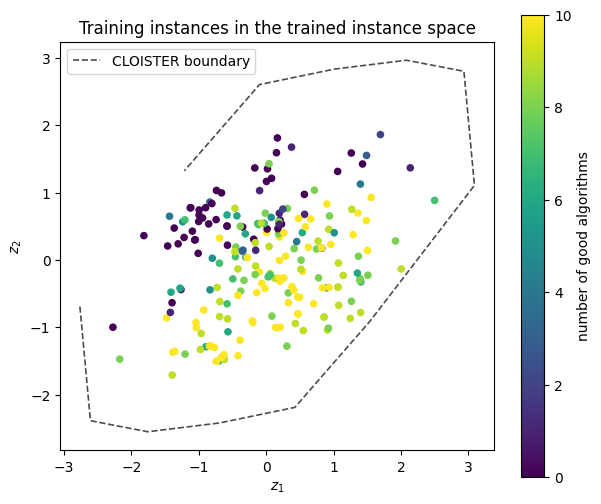

In [4]:
z = np.asarray(space.model.pilot.z)
z_edge = np.asarray(space.model.cloister.z_edge)

fig, ax = plt.subplots(figsize=(7, 6))
scatter = ax.scatter(
    z[:, 0], z[:, 1], c=space.model.data.num_good_algos, cmap="viridis", s=20
)
ax.plot(
    z_edge[:, 0], z_edge[:, 1], color="0.3", lw=1.2, ls="--", label="CLOISTER boundary"
)
fig.colorbar(scatter, ax=ax, label="number of good algorithms")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Training instances in the trained instance space")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

### The trained footprints

TRACE's summary gives each algorithm's *good*-footprint area and purity — the region where good
performance was statistically inferred, and how reliable that inference is.

In [5]:
space.model.trace.summary.set_index("Algorithm")[
    ["Area_Good", "Density_Good", "Purity_Good"]
]

,Area_Good,Density_Good,Purity_Good
Algorithm,,,
NB,4.953881,23.617846,1.0
LDA,5.267157,25.250816,1.0
QDA,1.558156,30.163858,1.0
CART,5.737132,25.622556,1.0
J48,5.386088,26.364218,1.0
KNN,5.968811,25.298169,1.0
L_SVM,5.078470,27.961177,1.0
poly_SVM,3.635626,25.855248,1.0
RBF_SVM,5.700867,25.434727,1.0


## Saving the model

`Model.save_to_csv()` and `Model.save_graphs()` write the tables and plots shown above (and more)
to disk, matching MATLAB's `obj.save()`/`scriptcsv`/`scriptpng`. There is no Python equivalent yet
of MATLAB's `model.mat`/`InstanceSpace.load()` round-trip (tracked as a roadmap item) — a Python
session must `build()` from scratch rather than reloading a previously saved model.

In [6]:
output_dir = Path("output")
output_dir.mkdir(exist_ok=True)
space.model.save_to_csv(output_dir)
space.model.save_graphs(output_dir)
print(f"wrote CSVs and graphs to {output_dir.resolve()}")

-> Writing the data on CSV files for posterior analysis.
-> Producing the plots.


/home/user/pyInstanceSpace/instancespace/_serialisers.py:182: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  trace_summary.rename(columns={"Algorithm": "Row"}, inplace=True)


/home/user/pyInstanceSpace/instancespace/_serialisers.py:556: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


wrote CSVs and graphs to /home/user/pyInstanceSpace/output


/home/user/pyInstanceSpace/instancespace/_serialisers.py:606: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  ax.scatter(


<Figure size 640x480 with 0 Axes>

## Setting up the test data

The test set uses the same metadata format as training: an `Instances` identifier column and
`feature_` columns (any `algo_` performance columns are optional and unused at inference). Load it
with `from_csv_file`.

In [7]:
test_metadata = from_csv_file(INPUT_DIR / "metadata_test.csv")
print(
    f"{len(test_metadata.instance_labels)} test instances, "
    f"{len(test_metadata.feature_names)} features"
)

235 test instances, 10 features


## The one call: `explore()`

To apply the model to the test instances you call `explore()` once. It runs every stage — PRELIM
scaling, SIFTED feature selection, the PILOT projection, the PYTHIA selectors and the TRACE
footprints — using the stored parameters, and returns an `ExploreResult` with the projected
coordinates, the per-algorithm predictions and the footprint membership. Nothing is re-fitted.

The log line below is `explore()` reporting that it detected a Python-built model and converted it
internally; the fitted scikit-learn model stays available on `space.model`.

In [8]:
result = space.explore(test_metadata)
print(
    f"z {result.z.shape}, y_hat {result.y_hat.shape}, "
    f"in_good {result.in_good.shape}, in_best {result.in_best.shape}"
)

2026-07-28 21:44:56.534 | WARNING  | instancespace.instance_space:_explore_prelim:696 - explore(): 9.8% of test instances have at least one feature outside the training bounds and were clipped to them. This suggests the test set may not be well represented by the trained instance space; consider retraining with a combined dataset.


z (235, 2), y_hat (235, 10), in_good (235, 10), in_best (235, 10)


## Inspecting it one stage at a time

`explore()` returns everything at once. `explore_stage_iter()` runs the same computation but yields each
stage's output as it is produced (`prelim`, `sifted`, `pilot`, `pythia`, `trace`), so you can look
at each stage before the next one runs. A few numbers per stage summarise how the test set moved
through the pipeline: how far the scaled features sit from the training centre, how many instances
project inside the region the model was trained on, and how many end up without a confident
prediction.

Because it is a generator, `explore_stage_iter()` produces each stage only when the next one is
requested, so you can stop after any stage — running the pipeline one stage at a time. For each
stage run and inspected on its own, see `docs/explore_validation.ipynb`.

In [9]:
z_train = np.asarray(space.model.pilot.z)
training_region = MultiPoint([tuple(p) for p in z_train]).convex_hull
n = len(test_metadata.instance_labels)

stages = {}
n_feat_in = None
for stage, output in space.explore_stage_iter(test_metadata):
    stages[stage] = output
    if stage == ExploreStage.PRELIM:
        n_feat_in = output.shape[1]
        beyond = np.mean(np.abs(output) > 3) * 100
        print(
            f"prelim : {beyond:.1f}% of scaled feature values fall beyond \u00b13 "
            f"standard deviations from the training mean"
        )
    elif stage == ExploreStage.SIFTED:
        print(f"sifted : kept {output.shape[1]} of {n_feat_in} features")
    elif stage == ExploreStage.PILOT:
        inside = sum(training_region.covers(Point(x, y)) for x, y in output)
        print(
            f"pilot  : {inside} of {n} test instances project inside the training region, "
            f"{n - inside} outside it"
        )
    elif stage == ExploreStage.PYTHIA:
        _, _, selection0 = output
        print(
            f"pythia : {int((selection0 < 0).sum())} of {n} instances have no algorithm "
            f"predicted good"
        )
    elif stage == ExploreStage.TRACE:
        in_good, _ = output
        outside = int((in_good.sum(axis=1) == 0).sum())
        print(f"trace  : {outside} of {n} instances fall outside every good footprint")

2026-07-28 21:44:56.601 | WARNING  | instancespace.instance_space:_explore_prelim:696 - explore(): 9.8% of test instances have at least one feature outside the training bounds and were clipped to them. This suggests the test set may not be well represented by the trained instance space; consider retraining with a combined dataset.


prelim : 0.0% of scaled feature values fall beyond ±3 standard deviations from the training mean
sifted : kept 6 of 10 features
pilot  : 232 of 235 test instances project inside the training region, 3 outside it
pythia : 43 of 235 instances have no algorithm predicted good
trace  : 62 of 235 instances fall outside every good footprint


### Projecting the data

PILOT projects each instance from feature space into the two-dimensional instance space (a single
matrix product with the trained projection matrix). Below, the test instances are drawn over the
training instances (grey) that define the space; test instances that fall outside the training
region (the convex hull of the training projection, dashed) are drawn in red.

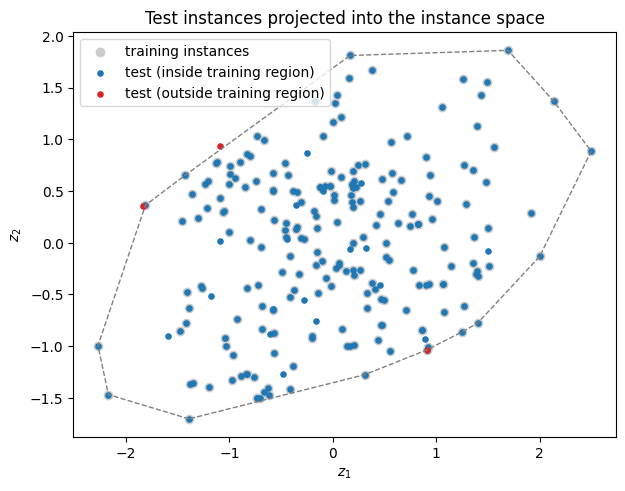

In [10]:
z = stages[ExploreStage.PILOT]
inside = np.array([training_region.covers(Point(x, y)) for x, y in z])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
ax.scatter(
    z[inside, 0],
    z[inside, 1],
    c="tab:blue",
    s=14,
    label="test (inside training region)",
)
ax.scatter(
    z[~inside, 0],
    z[~inside, 1],
    c="tab:red",
    s=14,
    label="test (outside training region)",
)
hx, hy = training_region.exterior.xy
ax.plot(hx, hy, color="0.5", lw=1.0, ls="--")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title("Test instances projected into the instance space")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

### Testing PYTHIA

For each algorithm, PYTHIA predicts whether it will perform well on an instance, and recommends the
algorithm with the highest precision-weighted confidence. Below, the test instances are coloured by
PYTHIA's good/bad prediction for one algorithm.

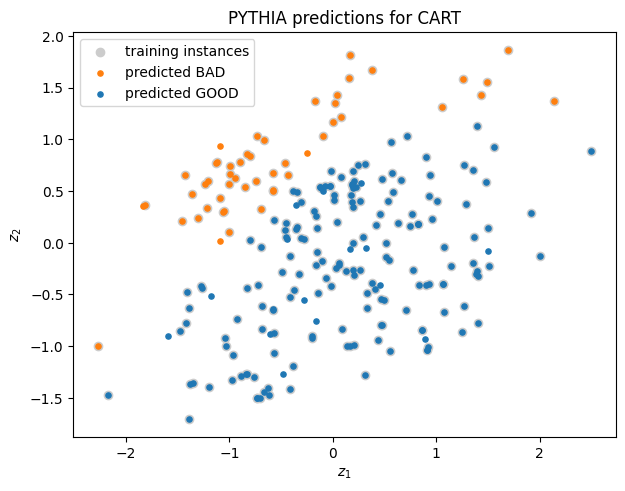

In [11]:
y_hat, pr0_hat, selection0 = stages[ExploreStage.PYTHIA]
algo_labels = space.model.data.algo_labels

algo = "CART" if "CART" in algo_labels else algo_labels[0]
j = algo_labels.index(algo)
good = y_hat[:, j]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
ax.scatter(z[~good, 0], z[~good, 1], c="tab:orange", s=14, label="predicted BAD")
ax.scatter(z[good, 0], z[good, 1], c="tab:blue", s=14, label="predicted GOOD")
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"PYTHIA predictions for {algo}")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

### Testing the footprints

TRACE records, for each algorithm, the region of the instance space where good performance was
statistically inferred at training time — its *footprint*. At inference each instance is checked
for membership in that region. Below, one algorithm's good footprint is drawn together with the
test instances that fall inside it.

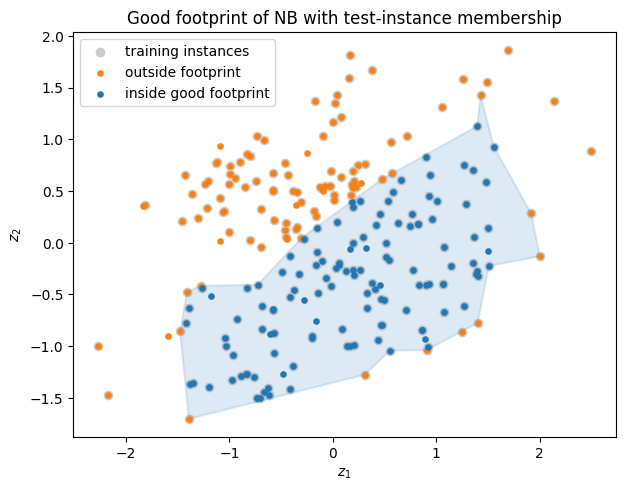

In [12]:
in_good, in_best = stages[ExploreStage.TRACE]

# pick an algorithm that has a non-empty good footprint
j = next(i for i, fp in enumerate(space.model.trace.good) if fp.polygon is not None)
algo = algo_labels[j]
footprint = space.model.trace.good[j].polygon
inside = in_good[:, j]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(z_train[:, 0], z_train[:, 1], c="0.8", s=36, label="training instances")
regions = footprint.geoms if isinstance(footprint, MultiPolygon) else [footprint]
for region in regions:
    xs, ys = region.exterior.xy
    ax.fill(
        xs, ys, facecolor="tab:blue", alpha=0.15, edgecolor="tab:blue", linewidth=1.5
    )
ax.scatter(
    z[~inside, 0], z[~inside, 1], c="tab:orange", s=14, label="outside footprint"
)
ax.scatter(
    z[inside, 0], z[inside, 1], c="tab:blue", s=14, label="inside good footprint"
)
ax.set_xlabel("$z_1$")
ax.set_ylabel("$z_2$")
ax.set_title(f"Good footprint of {algo} with test-instance membership")
ax.legend(loc="upper left")
ax.set_aspect("equal")
plt.show()

## Using this on your own data

To run this on your own problem, replace the two metadata paths in the setup cells with your own
files (same format as the repository README) and re-run. The whole workflow is just:

```python
space = InstanceSpace(train_metadata, options)
space.build()
result = space.explore(test_metadata)
```

Everything above is that call, opened up stage by stage.